# Exercise 8: Put all the concepts in Exercise 7 together

Skills:
* Apply all the concepts covered in Exercise 7 for a research question. Know when to use what concept.

References: 
* Exercise 7


### To Do

Narrow down the list of rail routes in CA to 3 groups. Use the SHN network to determine how much of the rail route runs near the SHN. We care only about rail routes that run entirely in CA (use stops to figure this out).

**Near** the interstate, US highway, or state highway is defined by being within a quarter mile. For this exercise, the distinction between interstate, US highway, and state highway is not important; treat any road that shows up in the dataset as "the SHN".

There are theoretically 3 groupings: 
* rail routes that are never within 0.25 miles of the SHN
* rail routes with > 0 but less than half of its length near the SHN 
* rail routes with at least half of its length near the SHN

Provide a table and a chart showing how many rail routes fall into each of the 3 groups by district.

Use a Markdown cell at the end to connect which geospatial concept was applied to which step of the process. The concepts that should be used are `projecting CRS`, `buffering`, `dissolve`, `clipping`, `spatial join`, `overlay`. 

In [1]:
import geopandas as gpd
import intake
import pandas as pd
from shared_utils import geography_utils
catalog = intake.open_catalog(
    "../_shared_utils/shared_utils/shared_data_catalog.yml")

/opt/conda/lib/python3.9/site-packages/geopandas/_compat.py:123: UserWarning: The Shapely GEOS version (3.11.1-CAPI-1.17.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.1-CAPI-1.16.0). Conversions between both will be slow.
  warnings.warn(
/tmp/ipykernel_796/1346341825.py:1: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  im

In [2]:
pd.options.display.max_columns = 100
pd.options.display.float_format = "{:.2f}".format
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

In [3]:
# Import data
districts = catalog.caltrans_districts.read()
highways = catalog.state_highway_network.read()

rail_group = ['0', '1', '2']
routes = catalog.ca_transit_routes.read()
rail_routes = routes[routes.route_type.isin(rail_group)
                    ].reset_index(drop=True)
stops = catalog.ca_transit_stops.read()
rail_stops= stops[stops.route_type.isin(rail_group)
                  ].reset_index(drop=True)

### Look at data

In [4]:
rail_stops.shape, rail_stops.crs

((2160, 9),
 <Geographic 2D CRS: EPSG:4326>
 Name: WGS 84
 Axis Info [ellipsoidal]:
 - Lat[north]: Geodetic latitude (degree)
 - Lon[east]: Geodetic longitude (degree)
 Area of Use:
 - name: World.
 - bounds: (-180.0, -90.0, 180.0, 90.0)
 Datum: World Geodetic System 1984 ensemble
 - Ellipsoid: WGS 84
 - Prime Meridian: Greenwich)

In [5]:
rail_stops.sample()

,agency,route_id,route_type,stop_id,stop_name,base64_url,uri,feed_url,geometry
644,Amtrak,88,2,NYP,Ny Moynihan Train Hall At Penn Station,aHR0cHM6Ly9jb250ZW50LmFtdHJhay5jb20vY29udGVudC9ndGZzL0dURlMuemlw,https://content.amtrak.com/content/gtfs/GTFS.zip,https://content.amtrak.com/content/gtfs/GTFS.zip,POINT (-73.99633 40.75104)


In [6]:
rail_routes.drop(columns = ['geometry']).sample()

,agency,route_id,route_type,route_name,shape_id,n_trips,base64_url,uri,feed_url
247,Sonoma-Marin Area Rail Transit,SMART,2,Sonoma County Airport to Larkspur,p_897680,19,aHR0cHM6Ly9hcGkuNTExLm9yZy90cmFuc2l0L2RhdGFmZWVkcz9vcGVyYXRvcl9pZD1TQQ==,https://api.511.org/transit/datafeeds?api_key={{ MTC_511_API_KEY}}&operator_id=SA,https://api.511.org/transit/datafeeds?operator_id=SA


In [7]:
rail_routes.shape, rail_routes.crs

((286, 10),
 <Geographic 2D CRS: EPSG:4326>
 Name: WGS 84
 Axis Info [ellipsoidal]:
 - Lat[north]: Geodetic latitude (degree)
 - Lon[east]: Geodetic longitude (degree)
 Area of Use:
 - name: World.
 - bounds: (-180.0, -90.0, 180.0, 90.0)
 Datum: World Geodetic System 1984 ensemble
 - Ellipsoid: WGS 84
 - Prime Meridian: Greenwich)

In [8]:
highways.drop(columns = ['geometry']).head(6)

,Route,County,District,RouteType,Direction
0,1,LA,7,State,NB
1,1,LA,7,State,SB
2,1,MEN,1,State,NB
3,1,MEN,1,State,SB
4,1,MON,5,State,NB
5,1,MON,5,State,SB


In [9]:
highways.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [10]:
# highways.sample(5).plot(column = 'Route')

In [11]:
# highways.sample(5).plot(column = 'Direction')

#### Find only stops in California

In [12]:
def california():
    # Dissolve district to be California only
    gdf = districts.dissolve()[['geometry','Shape__Area','Shape__Length']]
    return gdf

In [13]:
ca = california()

In [14]:
ca.crs == rail_stops.crs

True

In [15]:
# Find only stops in California
rail_ca_stops = rail_stops.clip(ca)

In [16]:
f"{len(rail_stops)-len(rail_ca_stops)} stops are not in CA"

'700 stops are not in CA'

In [17]:
rail_ca_stops.shape

(1460, 9)

In [18]:
rail_ca_stops.agency.unique()

array(['San Diego', 'Amtrak', 'North County', 'Metrolink', 'Caltrain',
       'ACE', 'Santa Clara Transit', 'Capitol Corridor', 'BART',
       'SFO AirTrain', 'Muni', 'Sacramento',
       'Sonoma-Marin Area Rail Transit'], dtype=object)

<AxesSubplot:>

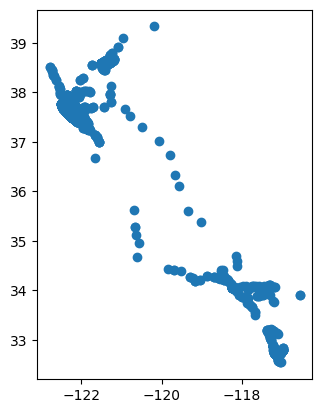

In [19]:
rail_ca_stops.plot()

In [127]:
rail_routes.columns

Index(['agency', 'route_id', 'route_type', 'route_name', 'shape_id', 'n_trips',
       'base64_url', 'uri', 'feed_url', 'geometry'],
      dtype='object')

#### Find only routes in California
* need to dissolve at some point?

In [23]:
def buffer_geo(gdf):
    gdf = gdf.to_crs("EPSG:2229")
    
    ft_in_mile = 5_280
    
    gdf = gdf.assign(
    geometry_buffered = gdf.geometry.buffer(0.25*5_280)
    )
    
    gdf = gdf.set_geometry('geometry_buffered')
    
    return gdf

In [24]:
rail_routes_buffered = buffer_geo(rail_routes)

In [25]:
# Why is it so much lighter
# Explore takes too long
# rail_routes_buffered.plot()

In [26]:
rail_routes.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [27]:
# rail_routes.plot()

In [28]:
# Find only stops in California by clipping w/o regard to stops
# rail_ca_routes_clipped = rail_routes_buffered.clip(ca.to_crs(rail_routes_buffered.crs))

In [29]:
# rail_ca_routes_clipped.route_id.nunique()

In [30]:
# rail_ca_routes_clipped.plot()

In [31]:
# Merge with routes?
""" rail_ca_routes_m = pd.merge(
    rail_ca_routes_clipped,
    rail_ca_stops[["agency","route_id","route_type"]],
    how = "inner",
    on = ["agency","route_id","route_type"],
    indicator = True
)"""

' rail_ca_routes_m = pd.merge(\n    rail_ca_routes_clipped,\n    rail_ca_stops[["agency","route_id","route_type"]],\n    how = "inner",\n    on = ["agency","route_id","route_type"],\n    indicator = True\n)'

In [32]:
# rail_ca_routes_m._merge.value_counts()

In [33]:
# type(rail_ca_routes_m)

In [34]:
# rail_ca_routes_m.route_id.nunique()

In [35]:
# rail_ca_routes_m = rail_ca_routes_m[['agency','route_id','route_type','route_name','geometry']]

In [36]:
# rail_routes_buffered.crs == rail_ca_stops.crs

In [37]:
# Why did the sjoin still include stuff 
# Outside of California?
rail_ca_routes_sjoin = gpd.sjoin(
    rail_routes_buffered,
    rail_ca_stops[['geometry']].to_crs(rail_routes_buffered.crs),
    how = "inner",
    predicate = "intersects"
)


In [38]:
rail_ca_routes_sjoin.shape

(22501, 12)

In [39]:
rail_ca_routes_sjoin.route_id.nunique()

46

In [40]:
# Check that route IDS are the same for each method
# They are all the same.

#clipped_routes = set(rail_ca_routes_clipped.route_id.unique().tolist())
#merged_routes = set(rail_ca_routes_m.route_id.unique().tolist())
#sjoin_routes = set(rail_ca_routes_sjoin.route_id.unique().tolist())

In [41]:
#clipped_routes - merged_routes - sjoin_routes

#### Highway intersection

In [42]:
highways_buffered = buffer_geo(highways)

In [49]:
highways_buffered = highways_buffered.assign(
    state = "CA")

In [131]:
highways_buffered.columns

Index(['Route', 'County', 'District', 'RouteType', 'Direction', 'geometry',
       'geometry_buffered', 'state'],
      dtype='object')

In [133]:
# highways_buffered.explore('Route')

In [58]:
highways_dissolved = highways_buffered.dissolve(by = 'state').reset_index()

In [60]:
highways_dissolved = highways_dissolved[['state','geometry_buffered','geometry']]

In [61]:
type(highways_dissolved)

geopandas.geodataframe.GeoDataFrame

In [63]:
highways_dissolved.shape

(1, 3)

<AxesSubplot:>

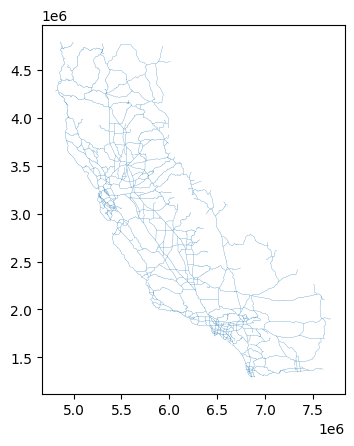

In [62]:
highways_dissolved.plot()

In [64]:
# Dissolve because highways have multiple directions
# highways_dissolved = highways_buffered.drop(columns = ['geometry','Direction']).dissolve(['Route','County','District', 'RouteType']).reset_index()

In [65]:
# highways_dissolved.drop(columns = ['geometry_buffered']).sample()

In [66]:
# highways_dissolved.shape, highways_buffered.shape

In [67]:
# highways_dissolved.Route.nunique(), highways_buffered.Route.nunique()

In [68]:
# highways_dissolved.plot(figsize=(4, 4), column="Route")

#### Overlay
* Need to dissolve at some point??

In [95]:
# Make sure original columns are retained.
# highways_dissolved['original_geometry_hwy'] = highways_dissolved.geometry_buffered

In [96]:
rail_ca_routes_sjoin['original_geometry_routes'] = rail_ca_routes_sjoin.geometry_buffered

In [97]:
highways_dissolved = highways_dissolved.to_crs(rail_ca_routes_sjoin.crs)

In [98]:
# Overlay highways with CA routes
overlay1 = gpd.overlay(
        highways_dissolved, rail_ca_routes_sjoin, how="intersection", keep_geom_type=False
    )


In [99]:
overlay1.geometry.name

'geometry'

In [100]:
overlay1.shape

(22501, 15)

In [101]:
overlay1.crs

<Projected CRS: EPSG:2229>
Name: NAD83 / California zone 5 (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - California - counties Kern; Los Angeles; San Bernardino; San Luis Obispo; Santa Barbara; Ventura.
- bounds: (-121.42, 32.76, -114.12, 35.81)
Coordinate Operation:
- name: SPCS83 California zone 5 (US Survey feet)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

* A route can intersect with multiple highways -> keep only the geometry with the largest area??

In [102]:
# Only want geometry of the intersecting route?
# Drop this to make dissolve run faster.
#overlay1 = overlay1.drop(columns = ["original_geometry_routes"])

In [103]:
type(overlay1), overlay1.route_id.nunique()

(geopandas.geodataframe.GeoDataFrame, 46)

In [104]:
overlay1.shape, overlay1.columns

((22501, 15),
 Index(['state', 'geometry_1', 'agency', 'route_id', 'route_type', 'route_name',
        'shape_id', 'n_trips', 'base64_url', 'uri', 'feed_url', 'geometry_2',
        'index_right', 'original_geometry_routes', 'geometry'],
       dtype='object'))

In [105]:
overlay1.route_id.value_counts()

L3             1839
M              1726
L4             1469
N              1349
Yellow-S       1082
L1             1008
K               922
Yellow-N        791
B7              765
510             689
78              663
L5              592
J               580
Blue Line       572
Red-N           568
Red-S           568
CC              566
84              551
Green-S         521
530             491
F               483
Green Line      457
507             456
T               363
36924           362
S               328
Orange Line     327
Green-N         295
Orange-N        295
Blue-S          247
Blue-N          247
533             233
520             211
Orange-S        134
519             121
26025           118
ACE             114
96              114
398             108
SMART            48
399              36
36930            32
87               18
Red Line         18
Beige-S          12
Beige-N          12
Name: route_id, dtype: int64

In [106]:
# Dissolve by district and route, keeping
# only the longest length
#overlay_agg = overlay1.dissolve(
#    by=["District", "route_id", "route_name"],
#     aggfunc={
#        "new_len": "max",
#       "original_routes_len": "max",).reset_index()

In [107]:
overlay_agg = overlay1.dissolve(by=["route_id", "route_name"]).reset_index()

In [108]:
overlay1.columns

Index(['state', 'geometry_1', 'agency', 'route_id', 'route_type', 'route_name',
       'shape_id', 'n_trips', 'base64_url', 'uri', 'feed_url', 'geometry_2',
       'index_right', 'original_geometry_routes', 'geometry'],
      dtype='object')

In [109]:
overlay_agg.shape

(47, 15)

In [110]:
overlay_agg.columns

Index(['route_id', 'route_name', 'geometry', 'state', 'geometry_1', 'agency',
       'route_type', 'shape_id', 'n_trips', 'base64_url', 'uri', 'feed_url',
       'geometry_2', 'index_right', 'original_geometry_routes'],
      dtype='object')

In [130]:
# overlay_agg.explore("route_name", legend = False)

In [115]:
overlay_agg = overlay_agg.assign(
    original_routes_len = overlay_agg.original_geometry_routes.length,
    new_len = overlay_agg.geometry_2.length)

In [114]:
overlay_agg.geometry_1.nunique()

1

#### Categorize
rail routes that are never within 0.25 miles of the SHN

rail routes with > 0 but less than half of its length near the SHN

rail routes with at least half of its length near the SHN

In [117]:
# Calculate percentage of new length against original one
overlay_agg = overlay_agg.assign(
    percentage = (overlay_agg.new_len / overlay_agg.original_routes_len) * 100)

In [118]:
def categorize_routes_shn(row):
    if 0 < row.percentage < 50:
        return "less than half of its length near the SHN"
    elif row.percentage > 50:
        return "at least half of its length near the SHN"
    else:
        return "never within 0.25 miles of the SHN"

In [119]:
overlay_agg["shn_category"] = overlay_agg.apply(categorize_routes_shn, axis=1)

In [120]:
overlay_agg.shn_category.value_counts()

less than half of its length near the SHN    40
at least half of its length near the SHN      7
Name: shn_category, dtype: int64

In [122]:
overlay_agg.groupby(['shn_category',]).agg({'route_id':'nunique'})

,route_id
shn_category,
at least half of its length near the SHN,7
less than half of its length near the SHN,40


In [124]:
rail_ca_routes_sjoin.columns

Index(['agency', 'route_id', 'route_type', 'route_name', 'shape_id', 'n_trips',
       'base64_url', 'uri', 'feed_url', 'geometry', 'geometry_buffered',
       'index_right', 'original_geometry_routes'],
      dtype='object')

In [128]:
# Plot the 2 original maps together
# base = highways_dissolved.plot(figsize=(24, 12),color='white', edgecolor='grey')
# rail_ca_routes_sjoin.plot(ax=base, column = 'route_id')

<b>Use a Markdown cell at the end to connect which geospatial concept was applied to which step of the process. The concepts that should be used are projecting CRS, buffering, dissolve, clipping, spatial join, overlay.</b>

* Project CRS: The datasets `routes`,`stops`, and `highways` used to answer this question are originally in the CRS 4326, which is in degrees. The question asks for the intersection between rail routes and highways, which requires a planar projection. As such, I had to project them to EPSG 2229, which is in feet. I also projected CRS when doing combining various GDFS together, as both GDFS need to be in the same CRS.
* Dissolve: 
    * I used `dissolve` to aggregate the `districts` up to the state level. `highways` is also quite granular, as it details which direction the highway goes and I dissolved it as well. 
    * After using `overlay` to find the length of the route that intersects with the highway, I used `dissolve` again. I only wanted the longest length for each District-Route ID-Route Name combination. (I guess I could just sort the gdf by longest length..)
* Clip: I clipped `stops` against `california` to get only the stops in California. 
* Buffer: The goal is to see which routes fall within 1/4 of a mile of a highway. I used `buffer` to buffer the aforementioned amount around each geometry for `highways` and `routes`. 
* Spatial Join: To find out which routes fall in California, I did a `sjoin` between `stops` and `routes`, using an `inner` join and `intersects`. I retained geometry from `routes` instead of `stops` to answer the question.
* Overlay: With the California only routes, I used `overlay` between `routes` and `highways`. I opted for `overlay` because I wanted an altered geometry to calculate the length of the route that actually intersects through the highway. I decided to use `keep_geom_type=False` to return all geometries. 